In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import os
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
BASE_PATH = "audio_data"
TRAIN_PATH = f"{BASE_PATH}/train"
TEST_PATH = f"{BASE_PATH}/test"

train_df = pd.read_csv(f'{BASE_PATH}/train.csv')
test_df = pd.read_csv(f'{BASE_PATH}/test.csv')

train_df['audio_path'] = train_df['audio'].apply(lambda x: os.path.join(TRAIN_PATH, x))
test_df['audio_path'] = test_df['audio'].apply(lambda x: os.path.join(TEST_PATH, x))

print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

Train samples: 1800
Test samples: 200


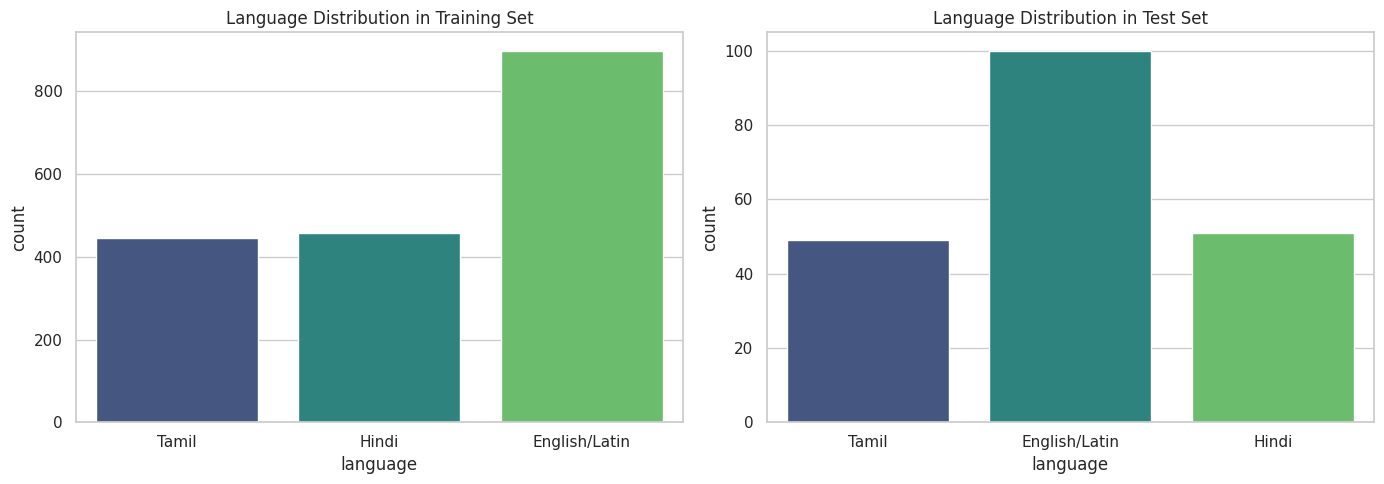

In [4]:
def detect_language(text):
    if not isinstance(text, str): return 'unknown'
    if re.search(r'[஀-௿]', text): return 'Tamil'
    if re.search(r'[ऀ-ॿ]', text): return 'Hindi'
    if re.search(r'[؀-ۿ]', text): return 'Arabic'
    if re.search(r'[一-鿿]', text): return 'Chinese'
    if re.search(r'[가-힯]', text): return 'Korean'
    if re.search(r'[぀-ヿ]', text): return 'Japanese'
    return 'English/Latin'

train_df['language'] = train_df['text'].apply(detect_language)
test_df['language'] = test_df['text'].apply(detect_language)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train_df, x='language', ax=axes[0], palette='viridis')
axes[0].set_title('Language Distribution in Training Set')
sns.countplot(data=test_df, x='language', ax=axes[1], palette='viridis')
axes[1].set_title('Language Distribution in Test Set')
plt.tight_layout()
plt.show()

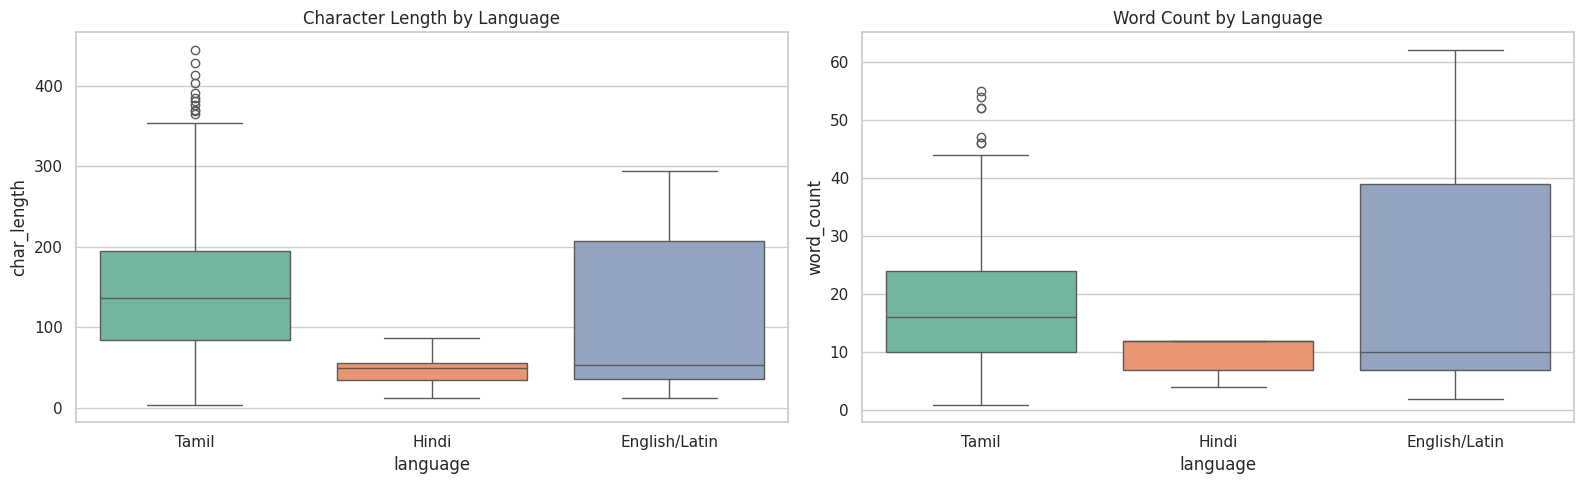

In [5]:
train_df['char_length'] = train_df['text'].astype(str).apply(len)
train_df['word_count'] = train_df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=train_df, x='language', y='char_length', ax=axes[0], palette='Set2')
axes[0].set_title('Character Length by Language')
sns.boxplot(data=train_df, x='language', y='word_count', ax=axes[1], palette='Set2')
axes[1].set_title('Word Count by Language')
plt.tight_layout()
plt.show()


Calculating Audio Durations:   0%|                      | 0/500 [00:00<?, ?it/s]


Calculating Audio Durations:   0%|              | 2/500 [00:00<02:58,  2.79it/s]


Calculating Audio Durations:  77%|████████▍  | 385/500 [00:00<00:00, 638.36it/s]


Calculating Audio Durations: 100%|███████████| 500/500 [00:00<00:00, 592.17it/s]

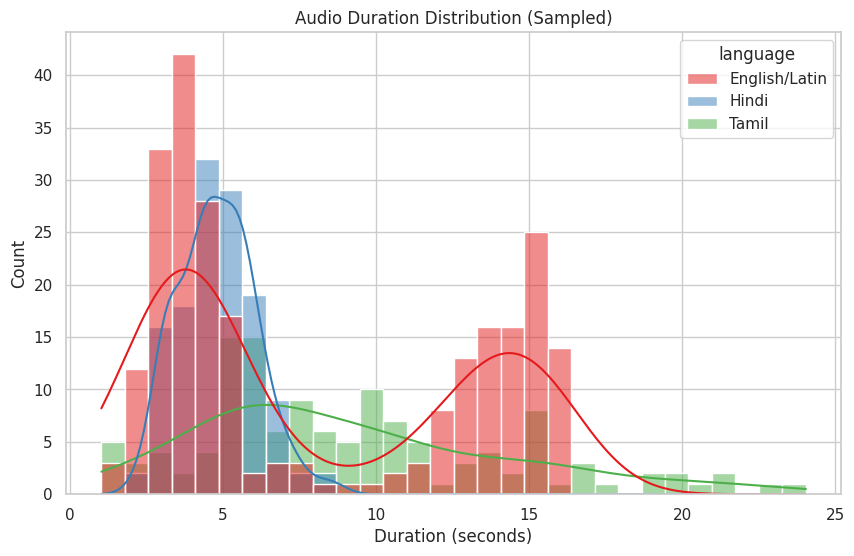

In [6]:
import librosa
from tqdm import tqdm

# Sample 500 files for duration analysis to save time
sample_df = train_df.sample(min(500, len(train_df)), random_state=42).copy()

def get_duration(path):
    try:
        return librosa.get_duration(path=path)
    except:
        return np.nan

tqdm.pandas(desc="Calculating Audio Durations")
sample_df['duration'] = sample_df['audio_path'].progress_apply(get_duration)

plt.figure(figsize=(10, 6))
sns.histplot(data=sample_df, x='duration', hue='language', kde=True, bins=30, palette='Set1')
plt.title('Audio Duration Distribution (Sampled)')
plt.xlabel('Duration (seconds)')
plt.show()

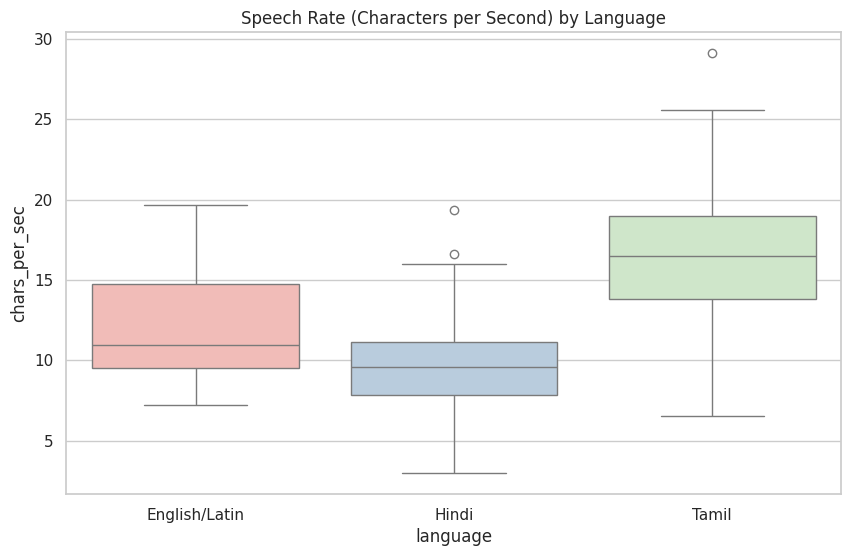

In [7]:
sample_df['chars_per_sec'] = sample_df['char_length'] / sample_df['duration']
plt.figure(figsize=(10, 6))
sns.boxplot(data=sample_df, x='language', y='chars_per_sec', palette='Pastel1')
plt.title('Speech Rate (Characters per Second) by Language')
plt.show()

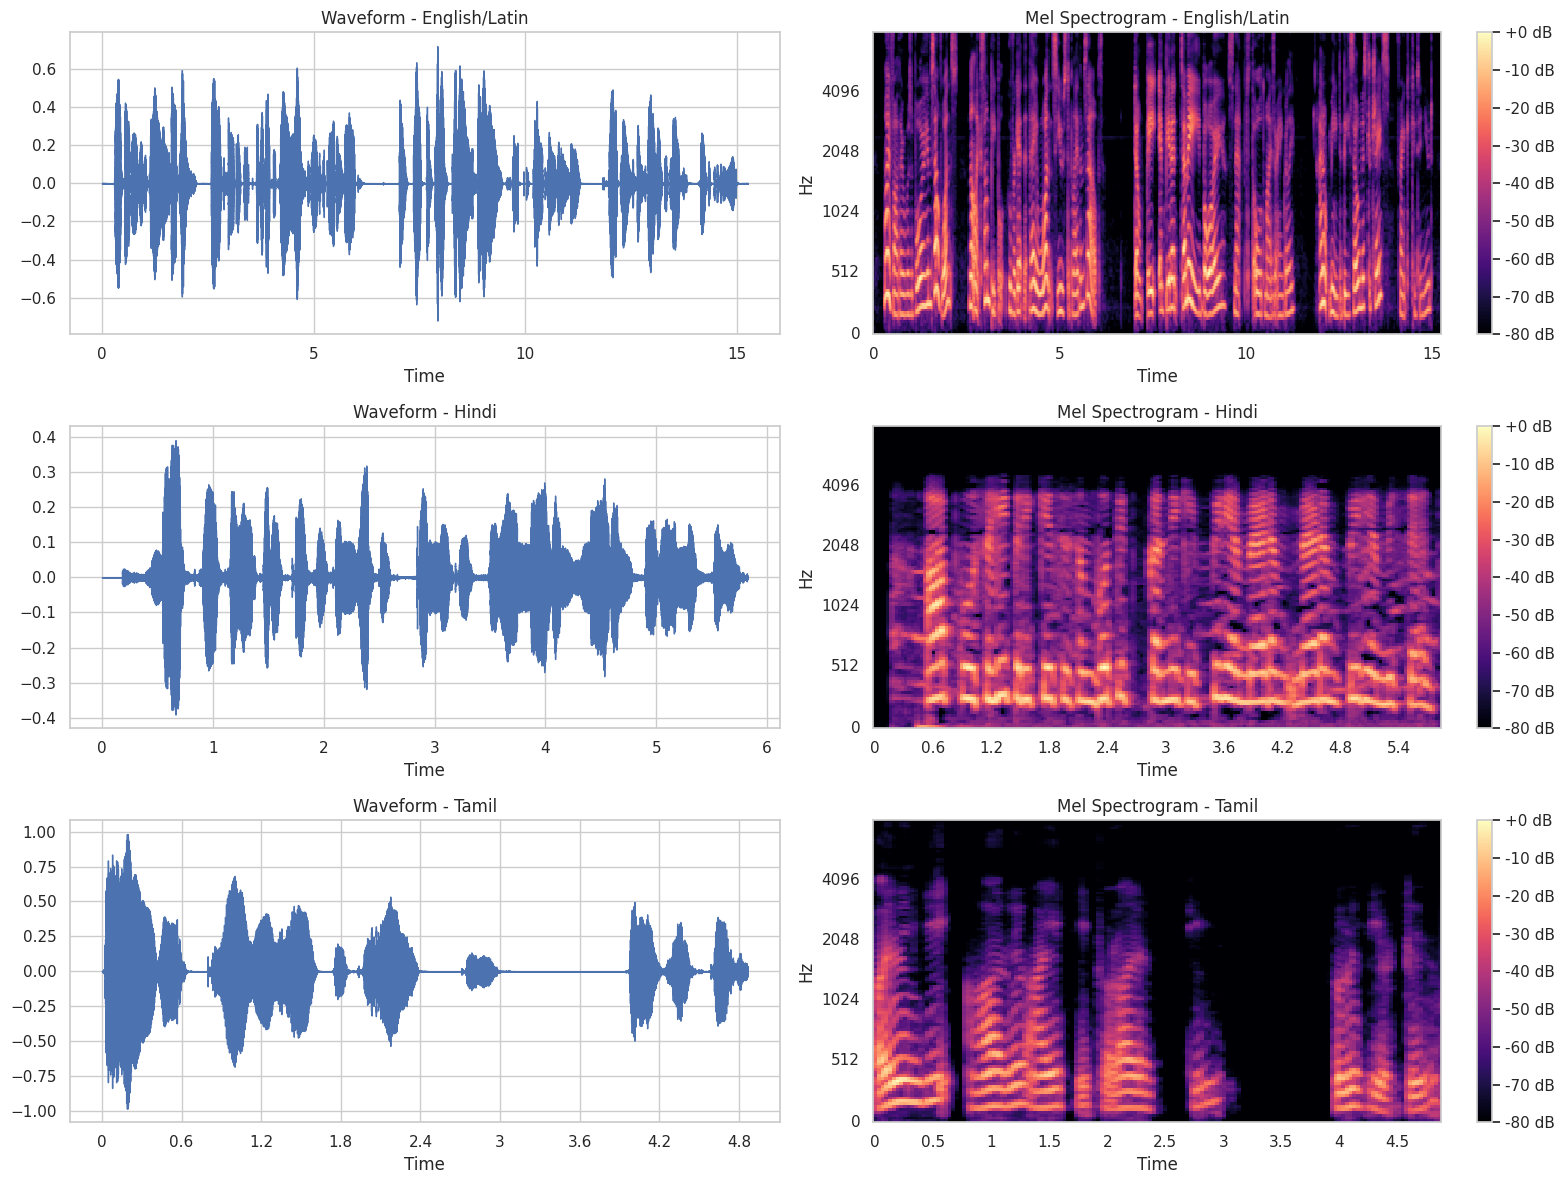

In [8]:
# Plot one sample from each language
unique_langs = sample_df['language'].unique()
fig, axes = plt.subplots(len(unique_langs), 2, figsize=(16, 4 * len(unique_langs)))

for i, lang in enumerate(unique_langs):
    row = sample_df[sample_df['language'] == lang].iloc[0]
    y, sr = librosa.load(row['audio_path'], sr=16000)
    
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
    axes[i, 0].set_title(f'Waveform - {lang}')
    
    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=axes[i, 1])
    fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')
    axes[i, 1].set_title(f'Mel Spectrogram - {lang}')

plt.tight_layout()
plt.show()